## Бізнес-контекст
Компанія HealthRisk Analytics продовжує покращувати модель прогнозування медичних ризиків.
Команда розробників хоче зрозуміти, як різні функції активації та прийоми регуляризації (Dropout, Batch Normalization) впливають на стабільність і якість навчання моделі. Ваше завдання — провести серію експериментів і порівняти результати.

## Завдання 1
 - Дослідіть вплив функцій активації на результати моделі.
 - Згенеруйте синтетичні дані для регресії за допомогою функції make_regression (2000 рядків, 10 ознак, noise=10, random_state=42).
 - Побудуйте модель MLP з одним прихованим прошарком із 32 нейронів.
 - Послідовно застосуйте різні функції активації: ReLU, Tanh, LeakyReLU, Swish.
 - Для кожної активації розрахуйте MAE і R² на тестовій вибірці.
 - Оформіть результати в таблиці:

| Активація | MAE | R² |
| :--- | :---: | :---: |
| ReLU | ... | ... |
| Tanh | ... | ... |
| LeakyReLU | ... | ... |
| Swish | ... | ... |

In [1]:
from sklearn.datasets import make_regression
X, y = make_regression(n_samples=2000, n_features=10, noise=10, random_state=42)
from sklearn.model_selection import train_test_split
xtrain, xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
xtrain = scaler.fit_transform(xtrain)
xtest = scaler.transform(xtest)

import torch
xtrain = torch.tensor(xtrain, dtype=torch.float32)
xtest = torch.tensor(xtest, dtype=torch.float32)
ytrain = torch.tensor(ytrain, dtype=torch.float32).reshape(-1,1) * 0.1
ytest = torch.tensor(ytest, dtype=torch.float32).reshape(-1,1) * 0.1

In [2]:
import torch.nn as nn

activators = {
    "Sigmoid": nn.Sigmoid(),
    "ReLU": nn.ReLU(),
    "Tanh": nn.Tanh(),
    "LeakyReLU": nn.LeakyReLU(),
    "SiLU": nn.SiLU(),
    "Swish": nn.SiLU(),
}

In [3]:
class Mlp(nn.Module):
    def __init__(self,
                input_size=10,
                hidden_size=32,
                output_size=1,
                activation="ReLU"
    ): 
        super(Mlp, self).__init__()
        self.activation = activators.get(activation, None)
        if self.activation is None :
            raise ValueError(f"Undefined activator '{activation}'")
        self.layers = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            self.activation,
            nn.Linear(hidden_size, output_size)
        )
    def forward(self, x, mode='test') :
        return self.layers(x)

In [4]:
def train_model(model, X, y, epochs=1000, lr=0.01) :
    criterion = nn.functional.mse_loss
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    losses = [*range(epochs)]
    for epoch in range(epochs) : 
        output = model(X, 'train')
        loss = criterion(output, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        losses[epoch] = loss.item()
    return losses

In [5]:
mlps = { k: Mlp(activation=k) for k in activators.keys() }
#mlps

In [6]:
def train_models_set(mlps, xtrain, ytrain) :
    losses = {}
    predictions = {}
    for k, mlp in mlps.items():
        losses[k] = train_model(mlp, xtrain, ytrain)
        with torch.no_grad():
            predictions[k] = mlp(xtest)
    return losses, predictions

In [7]:
losses, predictions = train_models_set(mlps, xtrain, ytrain)
        
print(*zip(*(predictions[k][:5] for k in mlps.keys()), ytest[:5]), sep='\n')

(tensor([31.7890]), tensor([32.1131]), tensor([32.9533]), tensor([32.1037]), tensor([32.2694]), tensor([32.1789]), tensor([31.9132]))
(tensor([0.6629]), tensor([1.3863]), tensor([0.6949]), tensor([0.1061]), tensor([0.4466]), tensor([0.7244]), tensor([-0.5455]))
(tensor([-14.7500]), tensor([-13.5115]), tensor([-13.5165]), tensor([-13.4630]), tensor([-13.4551]), tensor([-13.5350]), tensor([-12.4506]))
(tensor([17.6695]), tensor([15.9780]), tensor([16.1057]), tensor([15.9154]), tensor([15.9027]), tensor([16.0212]), tensor([17.3213]))
(tensor([12.4740]), tensor([11.5795]), tensor([11.7935]), tensor([11.9448]), tensor([11.7390]), tensor([11.7130]), tensor([12.9853]))


In [8]:
from sklearn.metrics import mean_absolute_error, r2_score
import pandas as pd

# Перетворюємо ytest у формат numpy масиву та згладжуємо
y_true = ytest.detach().cpu().numpy().flatten()

results = []

# Перебираємо активації, які є у вашому словнику mlps
for k in mlps.keys():
    # Отримуємо прогноз моделі, перетворюємо в numpy та згладжуємо
    y_pred = predictions[k].detach().cpu().numpy().flatten()
    
    # Рахуємо метрики
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    # Додаємо в список результатів
    results.append({
        "Активація": k,
        "MAE": round(mae, 4),
        "R²": round(r2, 4)
    })

# Створюємо датафрейм та виводимо у форматі Markdown
df_results = pd.DataFrame(results)
#print(df_results.to_markdown(index=False))
df_results

,Активація,MAE,R²
0,Sigmoid,1.3199,0.9905
1,ReLU,0.8920,0.9970
2,Tanh,0.8863,0.9967
3,LeakyReLU,0.8681,0.9972
4,SiLU,0.8508,0.9973
5,Swish,0.8591,0.9973


In [9]:
from IPython.display import Markdown as md
import sklearn.metrics as sm

def score_table(ytest, predictions):
    return md("\n".join((
        "|Активація|MAE|R²|",
        "|-|-|-|",
        *(f"|{k}|{sm.mean_absolute_error(ytest, v):.4f}|{sm.r2_score(ytest, v):.4f}|" for k, v in predictions.items())
    )))

score_table(ytest, predictions)

|Активація|MAE|R²|
|-|-|-|
|Sigmoid|1.3199|0.9905|
|ReLU|0.8920|0.9970|
|Tanh|0.8863|0.9967|
|LeakyReLU|0.8681|0.9972|
|SiLU|0.8508|0.9973|
|Swish|0.8591|0.9973|

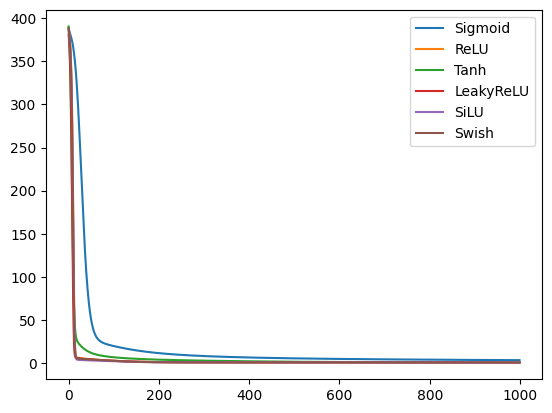

In [10]:
import matplotlib.pyplot as plt

def plot_losses(losses): 
    _, ax = plt.subplots()
    for k, v in losses.items():
        ax.plot(v, label=k)
    ax.legend()
    plt.show()
plot_losses(losses)

## Завдання 2
Додайте Dropout і проаналізуйте вплив регуляризації.
 - Використовуйте ту саму архітектуру MLP.
 - Додайте шар torch.nn.Dropout(p=0.3) після прихованого шару.
 - Порівняйте результати до і після застосування Dropout за MAE і R².
 - Зробіть висновок: чи допомагає Dropout уникнути перенавчання?

In [11]:
class Mlp(nn.Module):
    def __init__(self,
                input_size=10,
                hidden_size=32,
                output_size=1,
                activation="ReLU"
    ): 
        super(Mlp, self).__init__()
        self.activation = activators.get(activation, None)
        if self.activation is None :
            raise ValueError(f"Undefined activator '{activation}'")
        self.hidden = nn.Linear(input_size, hidden_size)
        self.dropout = nn.Dropout(p=0.3)
        self.output = nn.Linear(hidden_size, output_size)
    def forward(self, x, mode='test') :
        x = self.hidden(x)
        x = self.activation(x)
        if mode != 'test' :
            x = self.dropout(x)
        x = self.output(x)
        return x

In [12]:
mlps_d = { k: Mlp(activation=k) for k in activators.keys() }
losses_d, predictions_d = train_models_set(mlps_d, xtrain, ytrain)
        
print(*zip(*(predictions_d[k][:5] for k in mlps_d.keys()), ytest[:5]), sep='\n')
score_table(ytest, predictions_d)

(tensor([32.1076]), tensor([31.1754]), tensor([29.0813]), tensor([31.6496]), tensor([31.2018]), tensor([31.3848]), tensor([31.9132]))
(tensor([0.1866]), tensor([0.1237]), tensor([-3.6837]), tensor([0.3077]), tensor([0.0757]), tensor([0.0517]), tensor([-0.5455]))
(tensor([-12.4819]), tensor([-12.9894]), tensor([-13.4090]), tensor([-13.1741]), tensor([-13.0197]), tensor([-12.9815]), tensor([-12.4506]))
(tensor([15.0926]), tensor([15.4236]), tensor([17.5966]), tensor([15.4804]), tensor([15.2090]), tensor([15.6860]), tensor([17.3213]))
(tensor([10.9840]), tensor([11.5420]), tensor([12.4932]), tensor([11.5554]), tensor([11.4070]), tensor([11.4915]), tensor([12.9853]))


|Активація|MAE|R²|
|-|-|-|
|Sigmoid|1.1029|0.9932|
|ReLU|0.9537|0.9966|
|Tanh|1.7973|0.9859|
|LeakyReLU|0.9568|0.9966|
|SiLU|0.9712|0.9964|
|Swish|0.8959|0.9970|

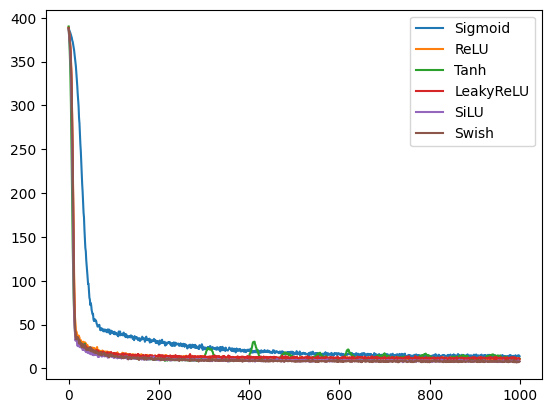

In [13]:
plot_losses(losses_d)

In [ ]:
Графік в другому випадку став більше рваним ніж в першому, через Dropout